In [1]:
# анализ показателя Херста
# фрактального броуновского
# движения методом R/S анализа

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки random
import random

# подключение функций fft, fftfreq
from scipy.fft import fft

# подключение библиотеки scipy.stats
import scipy.stats as sps

# инициализация генератора
# случайных чисел
random.seed()

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# оценку показателя Херста и
# соответствующие статистики
# в соответствие с методом
# R/S анализа
def RSA(X, L_min, L_max, dL, DrawPlot):
    # входные переменные:
    # X - координаты траектории
    #     фрактального броуновского движения
    # L_min - номер начального элемента массива Х,
    #         используемого для вычисления оценки
    #         показателя Херста
    # L_mах - номер последнего элемента массива Х,
    #         используемого для вычисления оценки
    #         показателя Херста
    # dL - шаг изменения номера
    #      элементов массива
    # DrawPlot - логическая переменная,
    #            DrawPlot = True/False - включение/выключение
    #            режима визуализации ФДБ и
    #            результатов вычисления
    #            показателя Херста

    # вычисление первых
    # разностей массива Х
    X1 = np.diff(X)

    # инициализация массивов R_S, Tau
    R_S = np.array([])
    dTau = np.array([])

    if L_max > len(X1):
        L_max = len(X1)
    # вычисление значений зависимости
    # [Tau_2 - Tau_1, R_S[Tau_2] - R_S[Tau_1]]
    for i in range(L_min, L_max, dL):
        R_s = np.array([])
        k = 1
        Tmp = np.zeros(i)
        while (k + 1) * i <= len(X):
            Tmp = X1[(k - 1) * i : i * k]
            Std_Tmp = np.std(Tmp, ddof=1)
            Mean_Tmp = np.mean(Tmp)
            Cumsum_Tmp = np.cumsum(Tmp - Mean_Tmp)
            R = np.max(Cumsum_Tmp) - np.min(Cumsum_Tmp)
            R_s = np.append(R_s, R / Std_Tmp)
            k = k + 1

        # вычисление значений зависимости
        # [log2(Tau_2 - Tau_1), log2(R_S[t_2] - R_S[t_1])]
        dTau = np.append(dTau, np.log2(i))
        R_S = np.append(R_S, np.log2(np.mean(R_s)))

    # вычисление коэффициентов
    # линейной аппроксимации зависимости
    # [log2(Tau_2 - Tau_1), log2(R_S[t_2] - R_S[t_1])]
    # и статистики линейной регрессии
    n = len(dTau)
    lin_model = sps.linregress(dTau, R_S)

    # вычисление параметров линейной регрессии
    a, b = lin_model.slope, lin_model.intercept

    # вычисление погрешности коэффицентов линейной регрессии
    a_err, b_err = lin_model.stderr, lin_model.intercept_stderr

    # вычисление доверительных интервалов линейной регрессии
    # с доверительной вероятностью 0.95
    a_conf = sps.t.interval(0.95, df=n - 2, loc=a, scale=a_err)
    b_conf = sps.t.interval(0.95, df=n - 2, loc=b, scale=b_err)

    if DrawPlot:
        # задание вида
        # аппроксимирующей функции
        def MK_Model(a, b):
            return lambda x: a * x + b

        # визуализация значений
        # зависимости [log2(t_2 - t_1), log2(R_S[t_2] - R_S[t_1])] и
        # результатов ее линейной аппроксимации
        plt.figure(figsize=(11, 5))

        ax = plt.subplot(1, 2, 1)
        plt.plot(X, "-k", lw=1)
        plt.grid(True)

        ax = plt.subplot(1, 2, 2)

        ax.scatter(dTau, R_S, s=0.3, color="black")
        ax.plot(dTau, MK_Model(a, b)(dTau), "-k", lw=1)
        ax.plot(dTau, MK_Model(a_conf[0], b_conf[0])(dTau), "--k", lw=1)
        ax.plot(dTau, MK_Model(a_conf[1], b_conf[1])(dTau), "--k", lw=1)
        ax.grid(True)

        plt.show()

        print(
            f"a = {a:0.4f} ± {a_err:0.4f}, \
          95%-ый доверительный интервал [{a_conf[0]:0.4f} ; {a_conf[1]:0.4f}]"
        )

        print(" ")

        print(
            f"b = {b:0.4f} ± {b_err:0.4f}, \
          95%-ый доверительный интервал [{b_conf[0]:0.4f} ; {b_conf[1]:0.4f}]"
        )

    return dTau, R_S


In [3]:
# Ячейка № 3

# задание функции,
# возвращающей координаты
# траектории фрактального
# броуновского движения,
# вычисленные на основе Фурье-фильтрации


def FBM_FF(H, Level):
    # входные переменные:
    # H - показатель Херста
    # Level - показатель степени числа 2

    # вычисление длины траектории
    N = 2**Level

    # инициализация комплекснозначного массива
    X = np.zeros(N) * 1j

    # вычисление координаты
    # начальной точки траектории
    X[0] = random.gauss(0, 1)

    # вычисление координат
    # фрактальной траектории
    # на основе Фурье-фильтрации
    X = np.zeros(N) * 1j
    X[0] = random.gauss(0, 100)
    for i in range(1, N // 2):
        Tmp = random.gauss(0, 100) * np.exp(2 * np.pi * 1j * random.uniform(0, 1))
        X[i] = Tmp / i ** (H + 0.5)
    Tmp = random.gauss(0, 100) * np.exp(2 * np.pi * 1j * random.uniform(0, 1))
    X[N // 2] = Tmp / (N // 2) ** (H + 0.5)
    for i in (N // 2 + 1, N - 1):
        X[i] = np.conj(X[N - i])
    X = fft(X)

    return np.real(X - X[0])

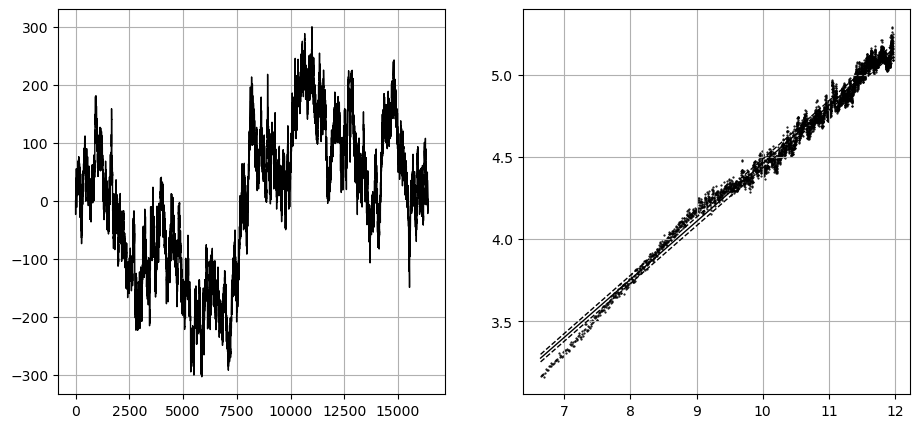

a = 0.3530 ± 0.0007,           95%-ый доверительный интервал [0.3517 ; 0.3543]
 
b = 0.9305 ± 0.0072,           95%-ый доверительный интервал [0.9164 ; 0.9447]


In [4]:
# Ячейка № 4

# задание значений показателя Херста
H1 = 0.3

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X1 = FBM_FF(H1, Max_Level)


L_min = 100
L_max = 4000
dL = 1
dTau_1, R_S_1 = RSA(X1, L_min, L_max, dL, True)

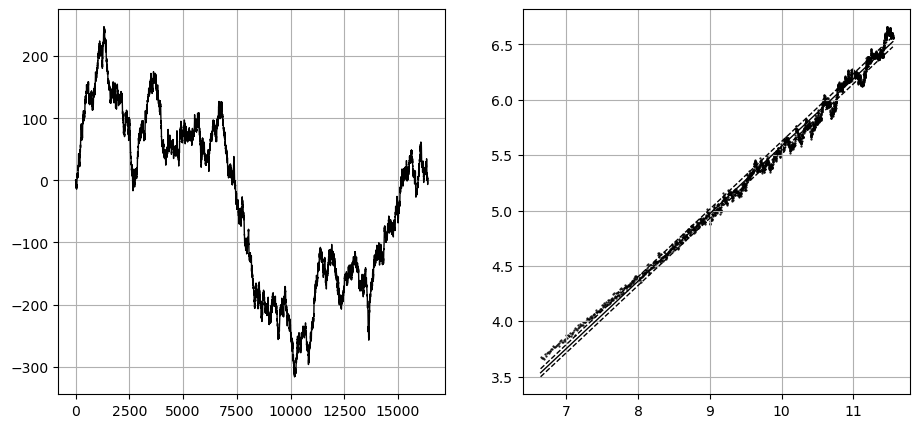

a = 0.6097 ± 0.0011,           95%-ый доверительный интервал [0.6076 ; 0.6118]
 
b = -0.5166 ± 0.0112,           95%-ый доверительный интервал [-0.5386 ; -0.4946]


In [5]:
# Ячейка № 5

# задание значений показателя Херста

H2 = 0.5

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X2 = FBM_FF(H2, Max_Level)

L_min = 100
L_max = 3000
dL = 1
dTau_2, R_S_2 = RSA(X2, L_min, L_max, dL, True)

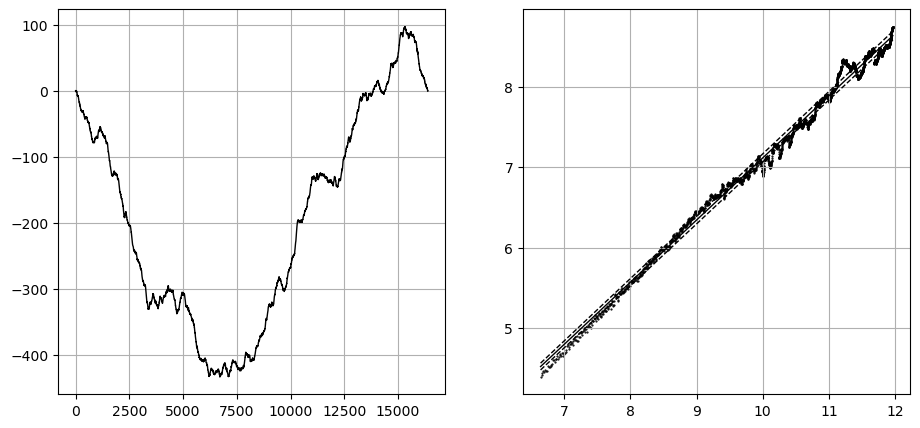

a = 0.7721 ± 0.0012,           95%-ый доверительный интервал [0.7697 ; 0.7745]
 
b = -0.6068 ± 0.0133,           95%-ый доверительный интервал [-0.6329 ; -0.5808]


In [6]:
# Ячейка № 6

# задание значений показателя Херста
H3 = 0.8

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# вычисление координат траектории ФБД
X3 = FBM_FF(H3, Max_Level)

L_min = 100
L_max = 4000
dL = 1
dTau_3, R_S_3 = RSA(X3, L_min, L_max, dL, True)